In [1]:
import pandas as pd

In [ ]:
print("Pandas funcionando!")

In [2]:
import pandas as pd

df = pd.read_excel("DADOS.xlsx")

df

,ID,Nome,Data de cadastro,Investiu?,Data do investimento,Dias até investir,Valor investido (R$)
0,1,Ana Beatriz,2026-01-05,Sim,2026-01-08 00:00:00,3,500
1,2,Lucas Oliveira,2026-01-12,Não,—,—,0
2,3,Gabriel Santos,2026-01-20,Sim,2026-01-28 00:00:00,8,1000
3,4,Mariana Costa,2026-02-03,Não,—,—,0
4,5,João Pedro,2026-02-15,Sim,2026-02-18 00:00:00,3,300
5,6,Beatriz Almeida,2026-02-22,Não,—,—,0
6,7,Rafael Souza,2026-03-05,Sim,2026-03-12 00:00:00,7,800
7,8,Camila Rodrigues,2026-03-14,Não,—,—,0
8,9,Matheus Lima,2026-03-25,Não,—,—,0
9,10,Júlia Martins,2026-04-02,Sim,2026-04-06 00:00:00,4,1200


In [3]:
# KPIs

total_usuarios = len(df)

usuarios_que_investiram = (df["Investiu?"] == "Sim").sum()

usuarios_que_nao_investiram = (df["Investiu?"] == "Não").sum()

total_investido = df["Valor investido (R$)"].sum()

taxa_conversao = (usuarios_que_investiram / total_usuarios) * 100

investimento_medio = df.loc[
    df["Investiu?"] == "Sim",
    "Valor investido (R$)"
].mean()

media_dias = pd.to_numeric(
    df["Dias até investir"],
    errors="coerce"
).mean()


print("===== KPIs =====")
print(f"Total de usuários: {total_usuarios}")
print(f"Usuários que investiram: {usuarios_que_investiram}")
print(f"Usuários que não investiram: {usuarios_que_nao_investiram}")
print(f"Total investido: R$ {total_investido:.2f}")
print(f"Taxa de conversão: {taxa_conversao:.2f}%")
print(f"Investimento médio: R$ {investimento_medio:.2f}")
print(f"Média de dias até investir: {media_dias:.2f} dias")

===== KPIs =====
Total de usuários: 20
Usuários que investiram: 9
Usuários que não investiram: 11
Total investido: R$ 7000.00
Taxa de conversão: 45.00%
Investimento médio: R$ 777.78
Média de dias até investir: 4.78 dias


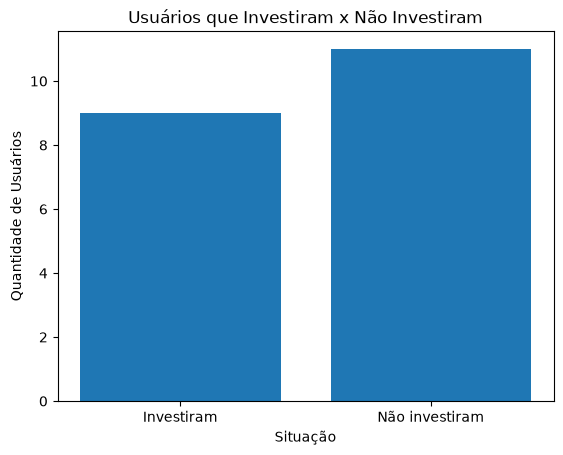

In [4]:
import matplotlib.pyplot as plt

# Quantidade de usuários que investiram e não investiram
investiram = (df["Investiu?"] == "Sim").sum()
nao_investiram = (df["Investiu?"] == "Não").sum()

# Dados do gráfico
categorias = ["Investiram", "Não investiram"]
valores = [investiram, nao_investiram]

# Criar gráfico
plt.bar(categorias, valores)

plt.title("Usuários que Investiram x Não Investiram")
plt.xlabel("Situação")
plt.ylabel("Quantidade de Usuários")

plt.show()

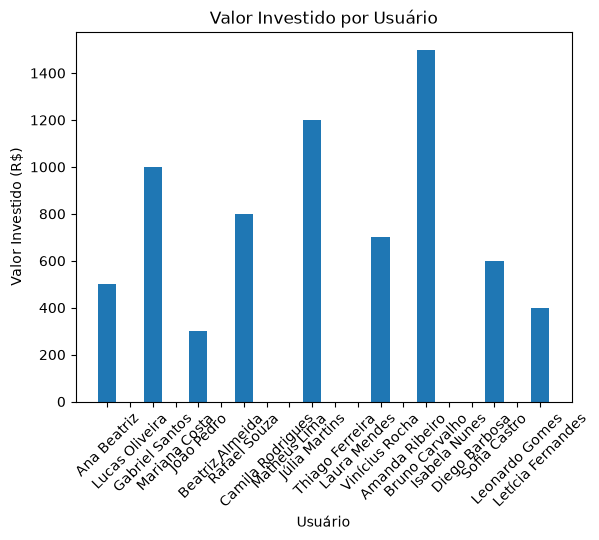

In [5]:
plt.bar(df["Nome"], df["Valor investido (R$)"])

plt.title("Valor Investido por Usuário")
plt.xlabel("Usuário")
plt.ylabel("Valor Investido (R$)")

plt.xticks(rotation=45)
plt.show()

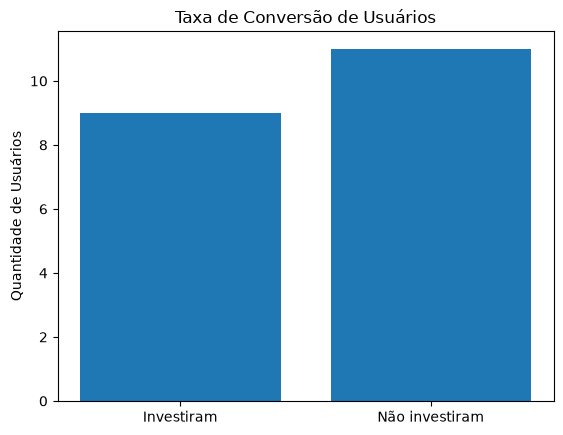

In [6]:
# Gráfico da taxa de conversão

categorias = ["Investiram", "Não investiram"]
valores = [usuarios_que_investiram, usuarios_que_nao_investiram]

plt.bar(categorias, valores)

plt.title("Taxa de Conversão de Usuários")
plt.ylabel("Quantidade de Usuários")

plt.show()

In [7]:
# Estatísticas do valor investido

media = df["Valor investido (R$)"].mean()
mediana = df["Valor investido (R$)"].median()
desvio_padrao = df["Valor investido (R$)"].std()

print("===== ESTATÍSTICAS =====")
print(f"Média: R$ {media:.2f}")
print(f"Mediana: R$ {mediana:.2f}")
print(f"Desvio padrão: R$ {desvio_padrao:.2f}")

===== ESTATÍSTICAS =====
Média: R$ 350.00
Mediana: R$ 0.00
Desvio padrão: R$ 471.84


In [20]:
# Preparar os dados para calcular a correlação

dias = pd.to_numeric(df["Dias até investir"], errors="coerce")
valores = pd.to_numeric(df["Valor investido (R$)"], errors="coerce")

# Calcular a correlação apenas onde existem números
correlacao = dias.corr(valores)

print(f"Correlação: {correlacao:.2f}")

Correlação: 0.12


In [15]:
# Análise de outliers

valores_investidos = pd.to_numeric(
    df["Valor investido (R$)"],
    errors="coerce"
).dropna()

Q1 = valores_investidos.quantile(0.25)
Q3 = valores_investidos.quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = valores_investidos[
    (valores_investidos < limite_inferior) |
    (valores_investidos > limite_superior)
]

print("===== ANÁLISE DE OUTLIERS =====")
print(f"Q1: R$ {Q1:.2f}")
print(f"Q3: R$ {Q3:.2f}")
print(f"IQR: R$ {IQR:.2f}")
print(f"Limite inferior: R$ {limite_inferior:.2f}")
print(f"Limite superior: R$ {limite_superior:.2f}")
print(f"Quantidade de outliers: {len(outliers)}")

print("\nValores considerados outliers:")
print(outliers)

===== ANÁLISE DE OUTLIERS =====
Q1: R$ 0.00
Q3: R$ 625.00
IQR: R$ 625.00
Limite inferior: R$ -937.50
Limite superior: R$ 1562.50
Quantidade de outliers: 0

Valores considerados outliers:
Series([], Name: Valor investido (R$), dtype: int64)


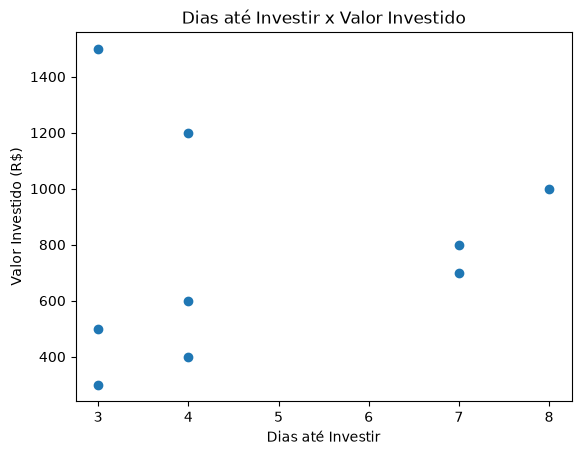

In [19]:
plt.scatter(dias, valores)

plt.title("Dias até Investir x Valor Investido")
plt.xlabel("Dias até Investir")
plt.ylabel("Valor Investido (R$)")

plt.show()

In [16]:
# Análise de assimetria

valores = pd.to_numeric(
    df["Valor investido (R$)"],
    errors="coerce"
).dropna()

assimetria = valores.skew()

print("===== ASSIMETRIA =====")
print(f"Coeficiente de assimetria: {assimetria:.2f}")

if assimetria > 0:
    print("A distribuição é assimétrica à direita (positiva).")
elif assimetria < 0:
    print("A distribuição é assimétrica à esquerda (negativa).")
else:
    print("A distribuição é aproximadamente simétrica.")

===== ASSIMETRIA =====
Coeficiente de assimetria: 1.16
A distribuição é assimétrica à direita (positiva).


In [17]:
# Conclusão da Análise de Dados

print("""
CONCLUSÃO DA ANÁLISE DE DADOS

A análise dos dados mostrou que 45% dos usuários realizaram investimentos,
totalizando R$ 7.000,00 investidos. O investimento médio entre os usuários
que investiram foi de R$ 777,78.

A análise estatística apresentou assimetria positiva de 1,16, indicando que
alguns valores de investimento mais altos influenciam a distribuição. Além
disso, a correlação entre os dias até realizar o investimento e o valor
investido foi de 0,12, indicando uma relação positiva, porém muito fraca.

Dessa forma, o principal ponto de atenção identificado é a conversão de
usuários em investidores. Como 55% dos usuários não realizaram investimentos,
a empresa pode buscar estratégias para aumentar essa conversão e incentivar
mais usuários a realizar seu primeiro investimento.
""")


CONCLUSÃO DA ANÁLISE DE DADOS

A análise dos dados mostrou que 45% dos usuários realizaram investimentos,
totalizando R$ 7.000,00 investidos. O investimento médio entre os usuários
que investiram foi de R$ 777,78.

A análise estatística apresentou assimetria positiva de 1,16, indicando que
alguns valores de investimento mais altos influenciam a distribuição. Além
disso, a correlação entre os dias até realizar o investimento e o valor
investido foi de 0,12, indicando uma relação positiva, porém muito fraca.

Dessa forma, o principal ponto de atenção identificado é a conversão de
usuários em investidores. Como 55% dos usuários não realizaram investimentos,
a empresa pode buscar estratégias para aumentar essa conversão e incentivar
mais usuários a realizar seu primeiro investimento.



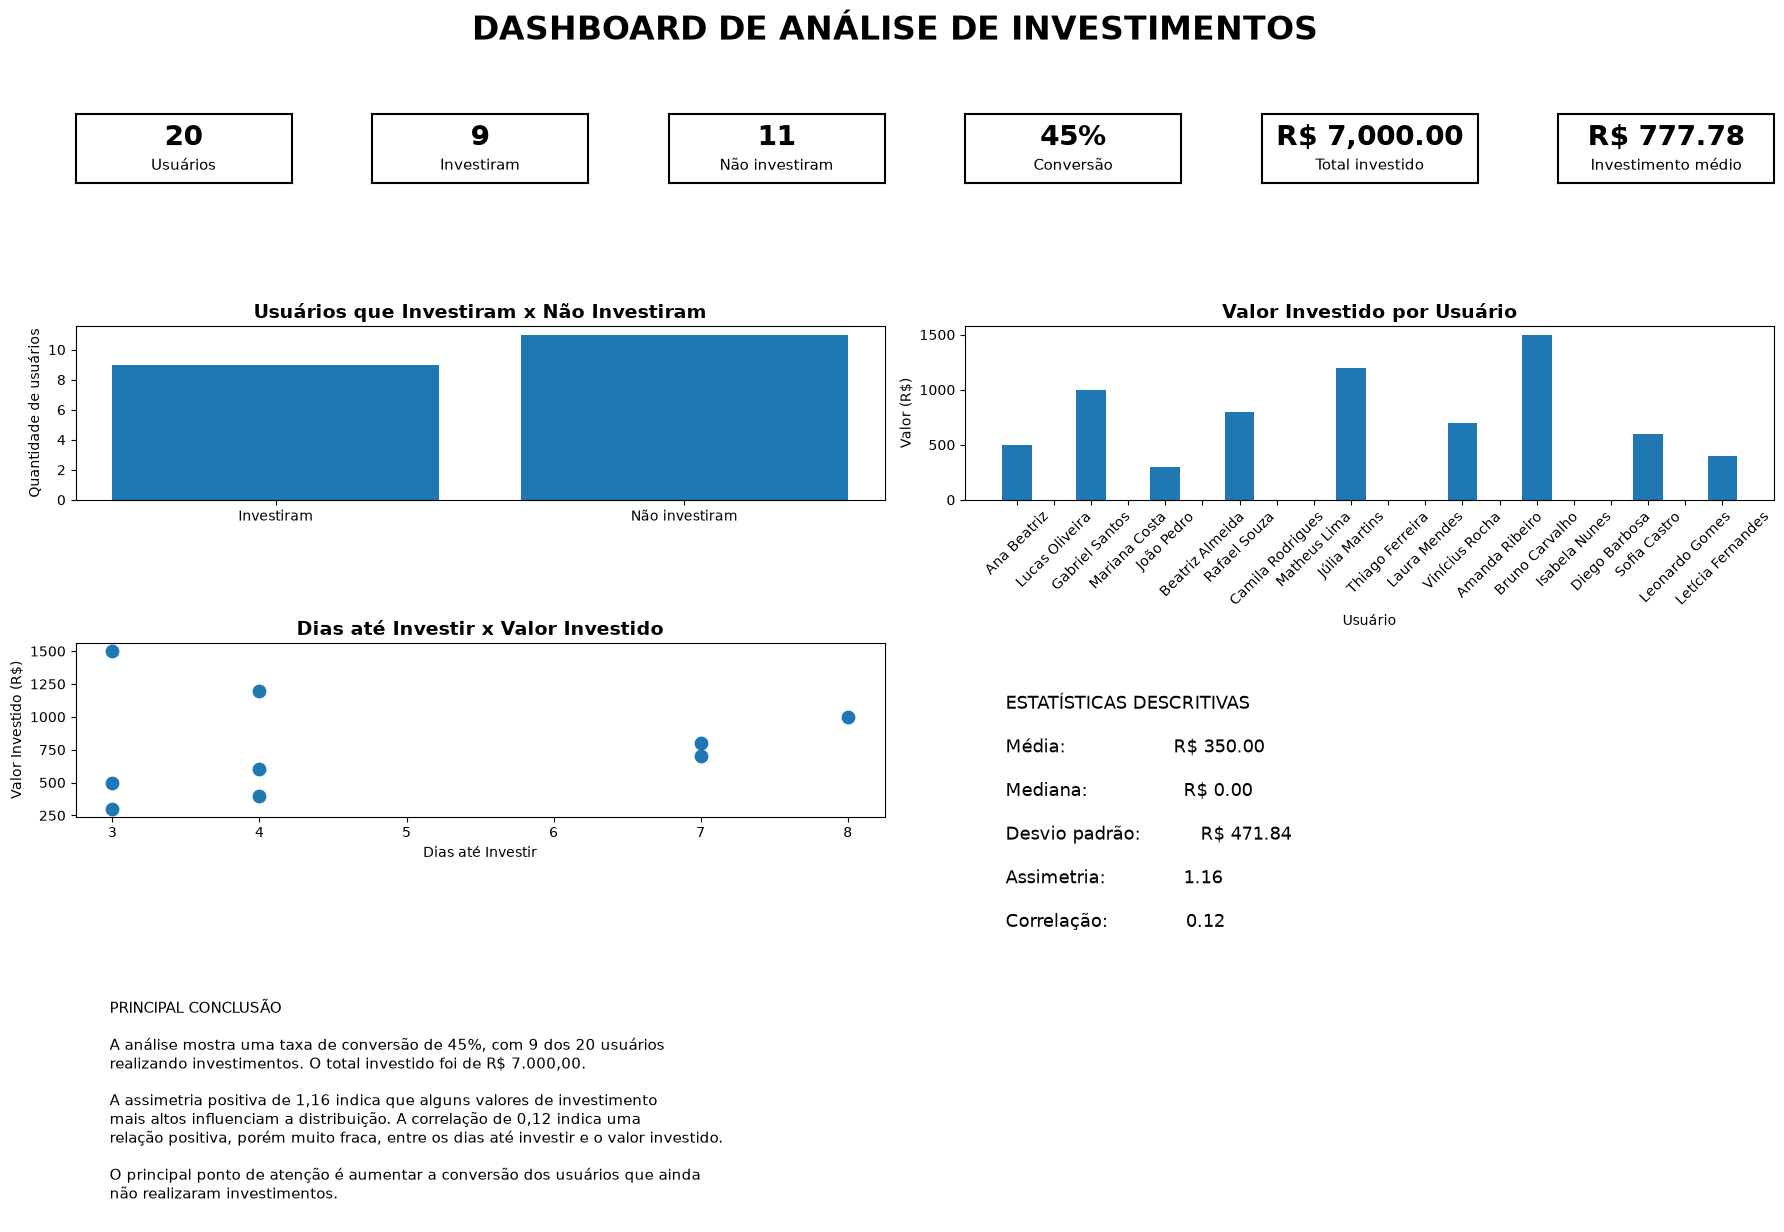

In [18]:
# ==========================================
# DASHBOARD DE ANÁLISE DE INVESTIMENTOS
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# ---------- DADOS ----------
df = pd.read_excel("DADOS.xlsx")

# ---------- KPIs ----------
total_usuarios = len(df)

usuarios_que_investiram = (
    df["Investiu?"] == "Sim"
).sum()

usuarios_que_nao_investiram = (
    df["Investiu?"] == "Não"
).sum()

valores = pd.to_numeric(
    df["Valor investido (R$)"],
    errors="coerce"
)

dias = pd.to_numeric(
    df["Dias até investir"],
    errors="coerce"
)

total_investido = valores.sum()

taxa_conversao = (
    usuarios_que_investiram / total_usuarios
) * 100

investimento_medio = df.loc[
    df["Investiu?"] == "Sim",
    "Valor investido (R$)"
].mean()

media = valores.mean()
mediana = valores.median()
desvio_padrao = valores.std()

assimetria = valores.skew()

correlacao = dias.corr(valores)


# ==========================================
# CRIAÇÃO DO DASHBOARD
# ==========================================

fig = plt.figure(figsize=(18, 12))

fig.suptitle(
    "DASHBOARD DE ANÁLISE DE INVESTIMENTOS",
    fontsize=24,
    fontweight="bold"
)

gs = GridSpec(
    4, 6,
    figure=fig,
    height_ratios=[1, 2.5, 2.5, 1.8]
)


# ==========================================
# CARDS DOS KPIs
# ==========================================

kpis = [
    ("Usuários", f"{total_usuarios}"),
    ("Investiram", f"{usuarios_que_investiram}"),
    ("Não investiram", f"{usuarios_que_nao_investiram}"),
    ("Conversão", f"{taxa_conversao:.0f}%"),
    ("Total investido", f"R$ {total_investido:,.2f}"),
    ("Investimento médio", f"R$ {investimento_medio:,.2f}")
]

for i, (titulo, valor) in enumerate(kpis):

    ax = fig.add_subplot(gs[0, i])

    ax.text(
        0.5, 0.65,
        valor,
        ha="center",
        va="center",
        fontsize=20,
        fontweight="bold"
    )

    ax.text(
        0.5, 0.25,
        titulo,
        ha="center",
        va="center",
        fontsize=11
    )

    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_linewidth(1.5)


# ==========================================
# GRÁFICO 1
# INVESTIRAM X NÃO INVESTIRAM
# ==========================================

ax1 = fig.add_subplot(gs[1, 0:3])

categorias = [
    "Investiram",
    "Não investiram"
]

quantidades = [
    usuarios_que_investiram,
    usuarios_que_nao_investiram
]

ax1.bar(categorias, quantidades)

ax1.set_title(
    "Usuários que Investiram x Não Investiram",
    fontsize=14,
    fontweight="bold"
)

ax1.set_ylabel("Quantidade de usuários")


# ==========================================
# GRÁFICO 2
# VALOR INVESTIDO POR USUÁRIO
# ==========================================

ax2 = fig.add_subplot(gs[1, 3:6])

ax2.bar(
    df["Nome"],
    valores
)

ax2.set_title(
    "Valor Investido por Usuário",
    fontsize=14,
    fontweight="bold"
)

ax2.set_xlabel("Usuário")
ax2.set_ylabel("Valor (R$)")

ax2.tick_params(
    axis="x",
    rotation=45
)


# ==========================================
# GRÁFICO 3
# DIAS ATÉ INVESTIR X VALOR
# ==========================================

ax3 = fig.add_subplot(gs[2, 0:3])

ax3.scatter(
    dias,
    valores,
    s=80
)

ax3.set_title(
    "Dias até Investir x Valor Investido",
    fontsize=14,
    fontweight="bold"
)

ax3.set_xlabel("Dias até Investir")
ax3.set_ylabel("Valor Investido (R$)")


# ==========================================
# ESTATÍSTICAS
# ==========================================

ax4 = fig.add_subplot(gs[2, 3:6])

ax4.axis("off")

estatisticas = f"""
ESTATÍSTICAS DESCRITIVAS

Média:                  R$ {media:.2f}

Mediana:                R$ {mediana:.2f}

Desvio padrão:          R$ {desvio_padrao:.2f}

Assimetria:             {assimetria:.2f}

Correlação:             {correlacao:.2f}
"""

ax4.text(
    0.05,
    0.85,
    estatisticas,
    fontsize=13,
    verticalalignment="top"
)


# ==========================================
# CONCLUSÃO
# ==========================================

ax5 = fig.add_subplot(gs[3, :])

ax5.axis("off")

conclusao = """
PRINCIPAL CONCLUSÃO

A análise mostra uma taxa de conversão de 45%, com 9 dos 20 usuários
realizando investimentos. O total investido foi de R$ 7.000,00.

A assimetria positiva de 1,16 indica que alguns valores de investimento
mais altos influenciam a distribuição. A correlação de 0,12 indica uma
relação positiva, porém muito fraca, entre os dias até investir e o valor investido.

O principal ponto de atenção é aumentar a conversão dos usuários que ainda
não realizaram investimentos.
"""

ax5.text(
    0.02,
    0.85,
    conclusao,
    fontsize=11,
    verticalalignment="top"
)


# ---------- AJUSTE FINAL ----------
plt.tight_layout(
    rect=[0, 0, 1, 0.95]
)

plt.show()